<a href="https://colab.research.google.com/github/eiyu18/pcvk/blob/main/week3_pcvk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


 Mengubah tingkat kecerahan citra 
 ---------------------------------
Masukan nilai kecerahan: 30


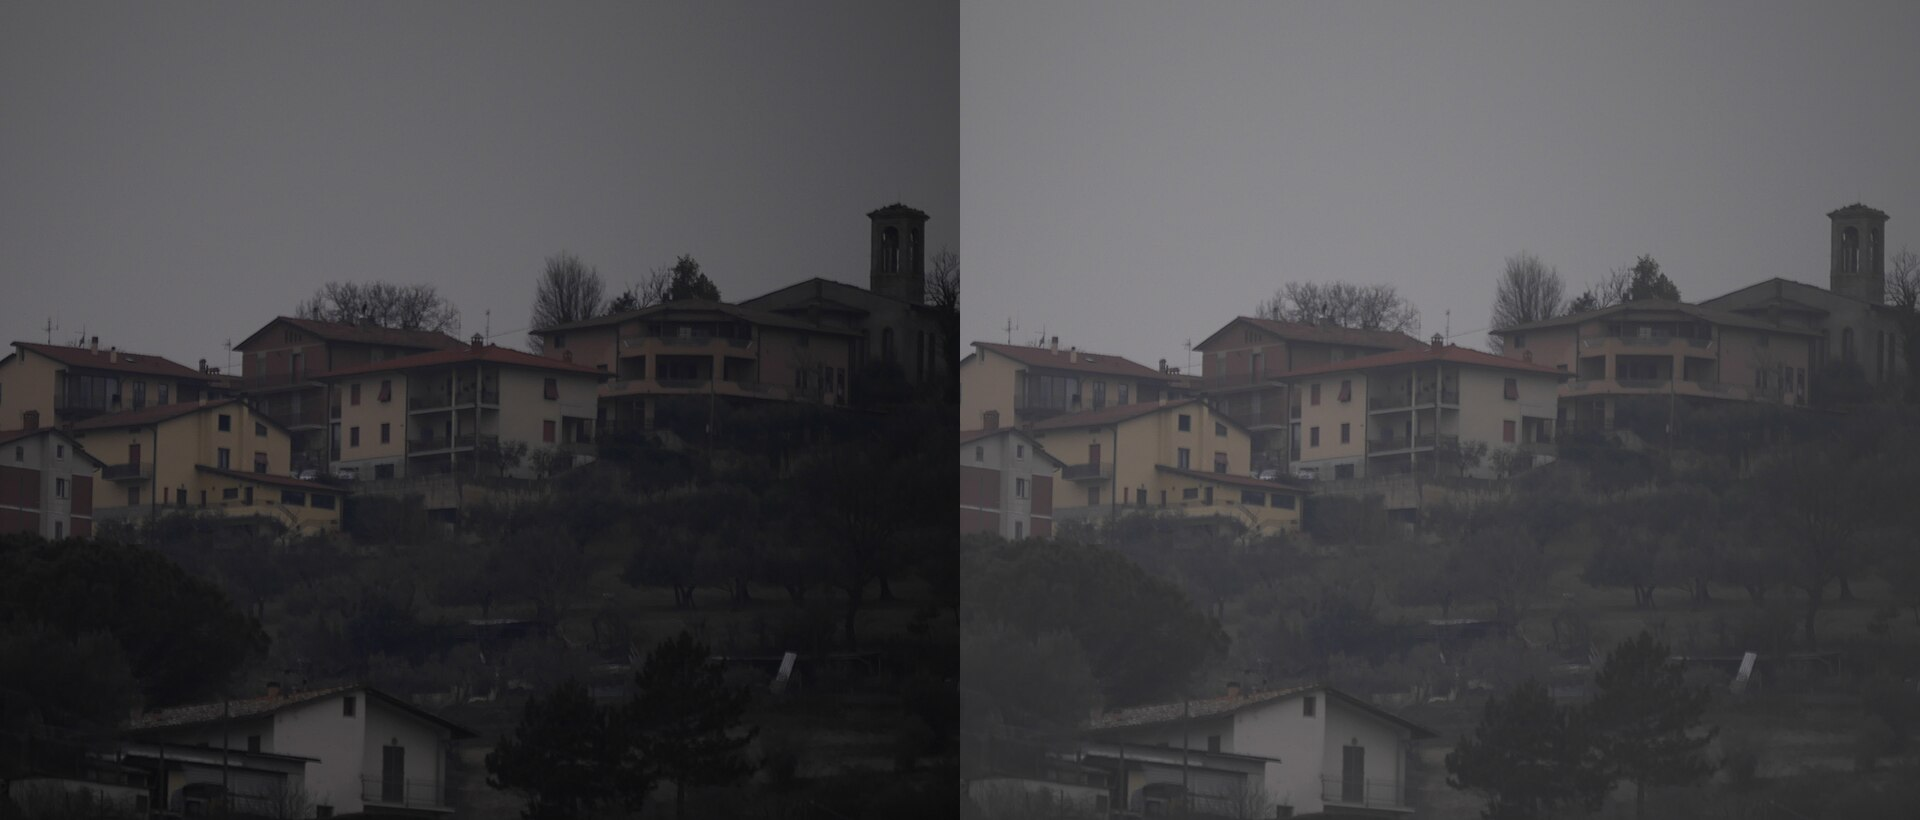

In [6]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra ')
print(' ---------------------------------')

try:
    brightness = int(input('Masukan nilai kecerahan: '))

    original = cv.imread('/content/drive/MyDrive/pcvk/Gambar/houses.jpg')

    if original is None:
        print("Error: Gambar tidak ditemukan. Pastikan path file benar.")
    else:
        brightness_image = np.zeros(original.shape, original.dtype)

        for y in range(original.shape[0]):
            for x in range(original.shape[1]):
                for c in range(original.shape[2]):
                    brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)

        final_frame = cv.hconcat((original, brightness_image))
        cv2_imshow(final_frame)

except ValueError:
    print('Error, not a number')

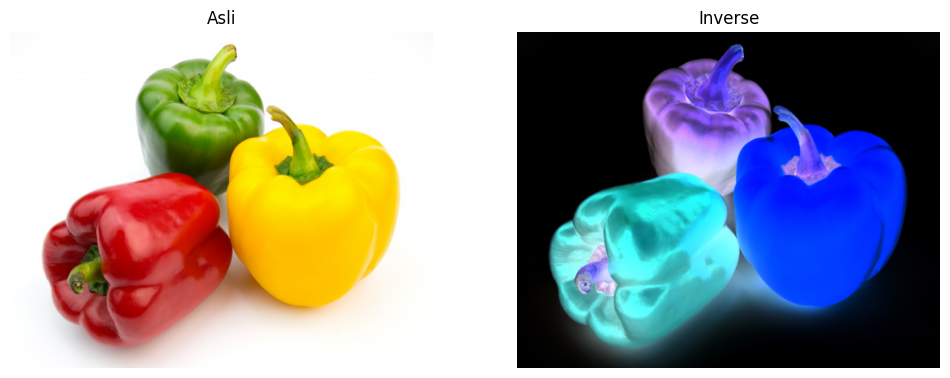

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/drive/MyDrive/pcvk/Gambar/peppers.jpg')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

inverted_img = 255 - img_rgb

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(inverted_img)
plt.title('Inverse')
plt.axis('off')

plt.show()

Mengubah kontras dan tingkat kecerahan citra
----------------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


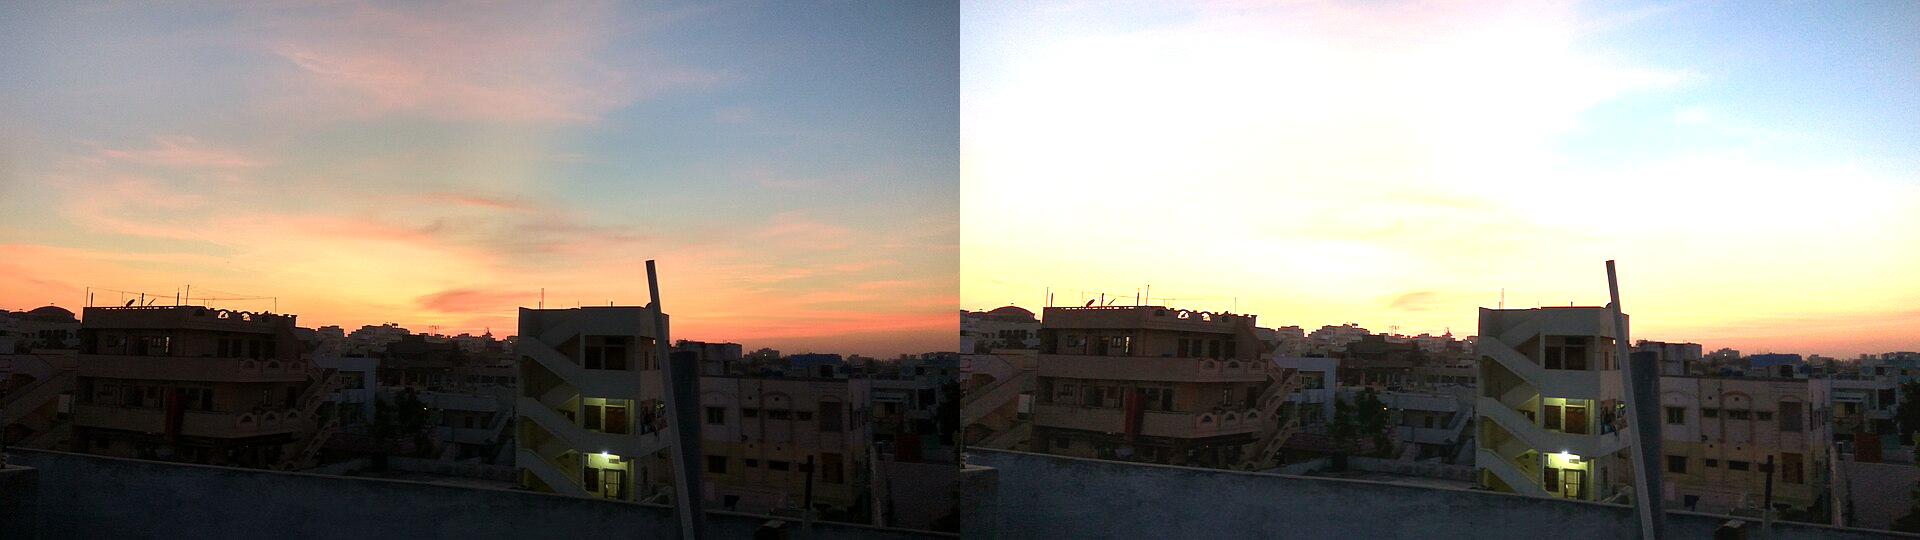

In [10]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('-' * 52)

try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))

    original = cv.imread('/content/drive/MyDrive/pcvk/Gambar/sunset.jpg')

    if original is None:
        print("Error: Gambar tidak ditemukan. Pastikan path file benar.")
    else:
        contrast_image = np.clip(contrast * original.astype(float) + brightness, 0, 255).astype(np.uint8)

        final_frame = cv.hconcat((original, contrast_image))

        cv2_imshow(final_frame)

except ValueError:
    print('Error: Masukkan angka yang valid.')

Mengubah tingkat kecerahan citra dengan Transformasi Log
--------------------------------------------------------
Masukkan nilai kecerahan: 50


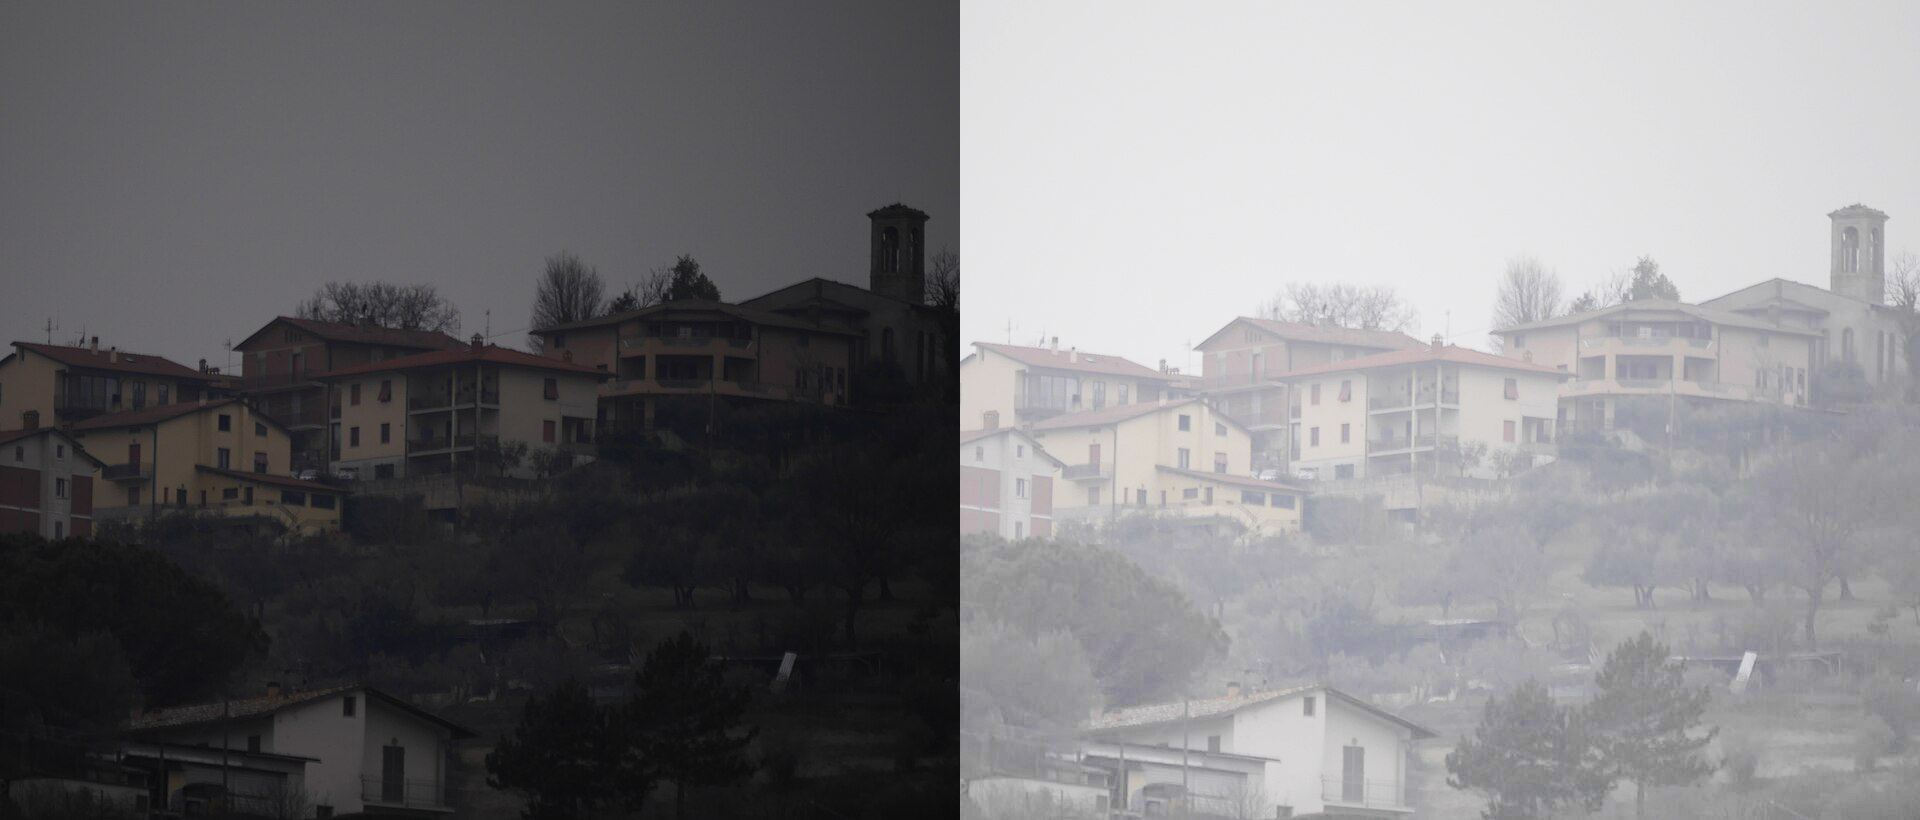

In [11]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('-' * 56)

try:
    # Accept the brightness constant (c) from the user
    c = int(input('Masukkan nilai kecerahan: '))

    # Load the original dark image
    # Update the path to match where your image is saved in Drive/Colab
    original = cv.imread('/content/drive/MyDrive/pcvk/Gambar/houses.jpg')

    if original is None:
        print("Error: Gambar tidak ditemukan. Pastikan path file benar.")
    else:
        # Apply the Log Transformation formula: s = c * log(1 + r)
        # 1. We convert the image to float64 to prevent calculation errors.
        # 2. np.log1p(x) is a numpy function that calculates log(1 + x) accurately.
        log_image = c * np.log1p(original.astype(np.float64))

        # Use np.clip as the Truncate function to ensure values stay within 0-255
        log_image = np.clip(log_image, 0, 255).astype(np.uint8)

        # Combine the original and processed images horizontally
        final_frame = cv.hconcat((original, log_image))

        # Display the result
        cv2_imshow(final_frame)

except ValueError:
    print('Error: Masukkan angka yang valid.')

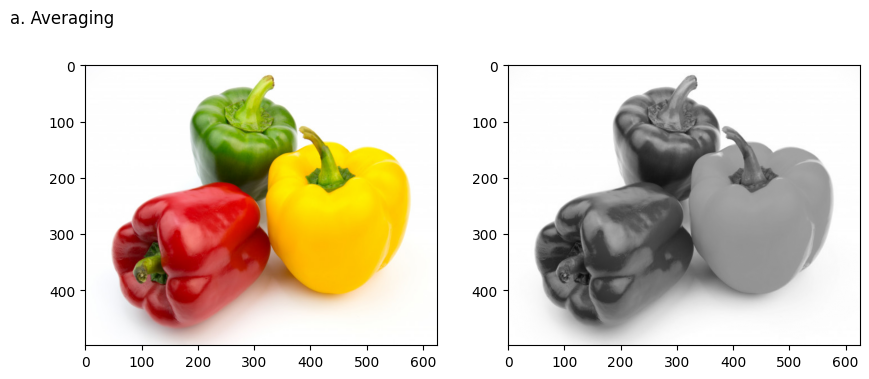

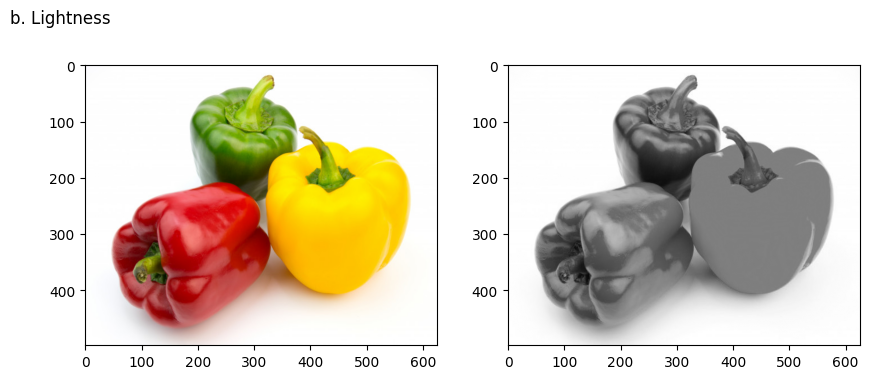

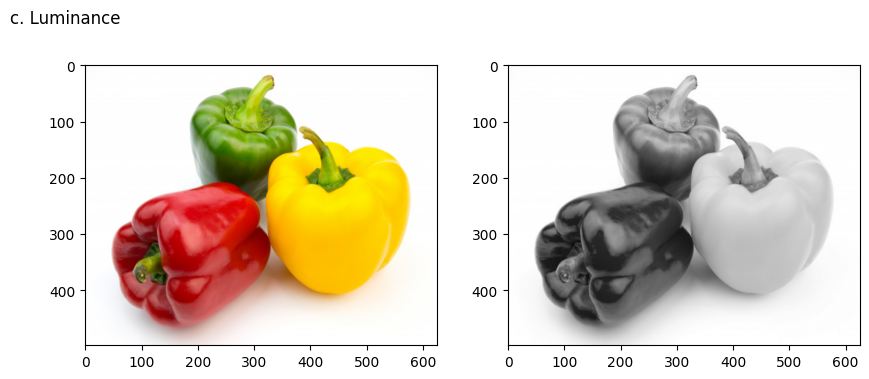

In [14]:
img = cv2.imread('/content/drive/MyDrive/pcvk/Gambar/peppers.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


R, G, B = cv2.split(img_rgb.astype(np.float32))

avg_gray = ((R + G + B) / 3).astype(np.uint8)

max_rgb = np.maximum(np.maximum(R, G), B)
min_rgb = np.minimum(np.minimum(R, G), B)
lightness_gray = ((max_rgb + min_rgb) / 2).astype(np.uint8)

luminance_gray = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

def plot_comparison(title, original_img, processed_img):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plt.figtext(0.05, 0.95, title, fontsize=12, ha='left')
    axes[0].imshow(original_img)
    axes[1].imshow(processed_img, cmap='gray', vmin=0, vmax=255)

    plt.show()
plot_comparison("a. Averaging", img_rgb, avg_gray)
plot_comparison("b. Lightness", img_rgb, lightness_gray)
plot_comparison("c. Luminance", img_rgb, luminance_gray)

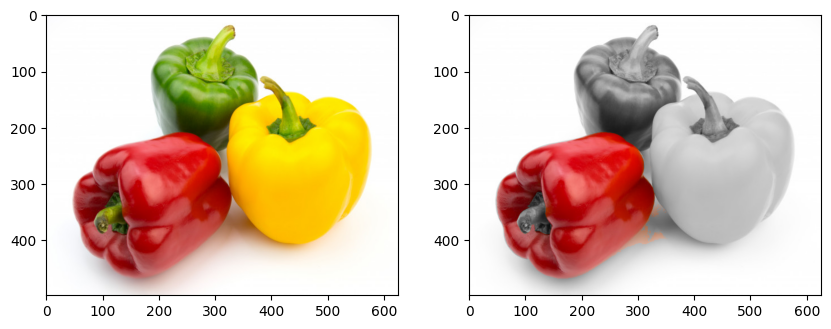

In [16]:
img = cv2.imread('/content/drive/MyDrive/pcvk/Gambar/peppers.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower_red1 = np.array([0, 70, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 70, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)
red_mask = mask1 | mask2


background_mask = cv2.bitwise_not(red_mask)


gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

gray_3channel = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

red_parts = cv2.bitwise_and(img_rgb, img_rgb, mask=red_mask)

gray_parts = cv2.bitwise_and(gray_3channel, gray_3channel, mask=background_mask)

final_image = cv2.add(red_parts, gray_parts)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_rgb)
axes[1].imshow(final_image)

plt.show()

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 0.5


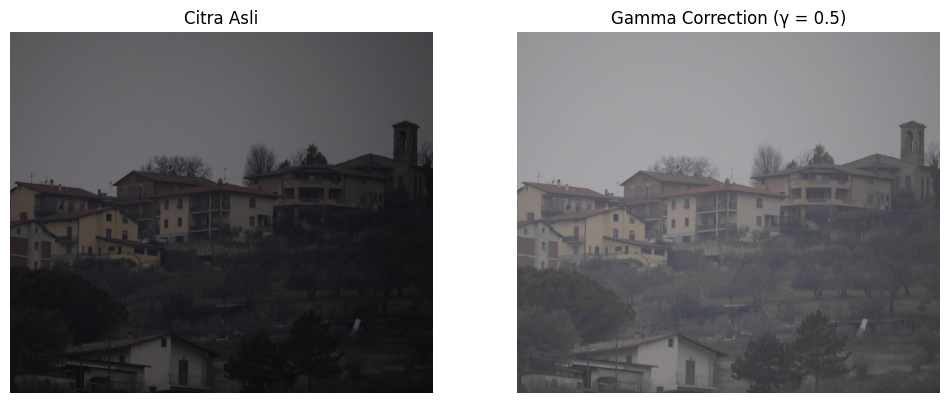

In [17]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
    img = cv2.imread('/content/drive/MyDrive/pcvk/Gambar/houses.jpg')

    if img is None:
        print("Error: Gambar tidak ditemukan.")
    else:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_normalized = img_rgb.astype(np.float32) / 255.0

        gamma_corrected = 255.0 * (img_normalized ** gamma)

        gamma_corrected = np.clip(gamma_corrected, 0, 255).astype(np.uint8)

        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        axes[0].imshow(img_rgb)
        axes[0].set_title('Citra Asli')
        axes[0].axis('off')

        axes[1].imshow(gamma_corrected)
        axes[1].set_title(f'Gamma Correction (γ = {gamma})')
        axes[1].axis('off')

        plt.show()

except ValueError:
    print('Error, not a number')

Masukkan bit depth tujuan (1-8): 3
Bit depth awal : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8


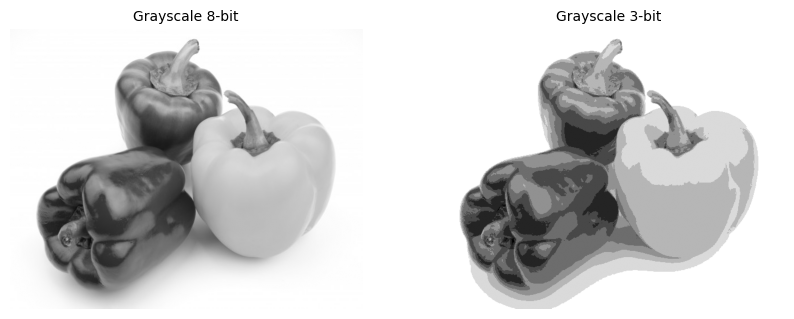

In [18]:
try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))

    jumlah_level = 2 ** bit_depth

    print(f'Bit depth awal : 8 bit')
    print(f'Bit depth tujuan: {bit_depth} bit')
    print(f'Jumlah level    : {jumlah_level}')

    level_step = 255.0 / (jumlah_level - 1)

    original = cv.imread('/content/drive/MyDrive/pcvk/Gambar/peppers.jpg', cv.IMREAD_GRAYSCALE)

    if original is None:
        print("Error: Gambar tidak ditemukan. Pastikan path file benar.")
    else:
        depth_image = np.zeros(original.shape, original.dtype)

        depth_image = np.round(original / level_step) * level_step

        depth_image = depth_image.astype(np.uint8)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(original, cmap='gray', vmin=0, vmax=255)
        axes[0].set_title('Grayscale 8-bit', fontsize=10)
        axes[0].axis('off')

        axes[1].imshow(depth_image, cmap='gray', vmin=0, vmax=255)
        axes[1].set_title(f'Grayscale {bit_depth}-bit', fontsize=10)
        axes[1].axis('off')

        plt.show()

except ValueError:
    print('Error: Masukkan angka yang valid.')

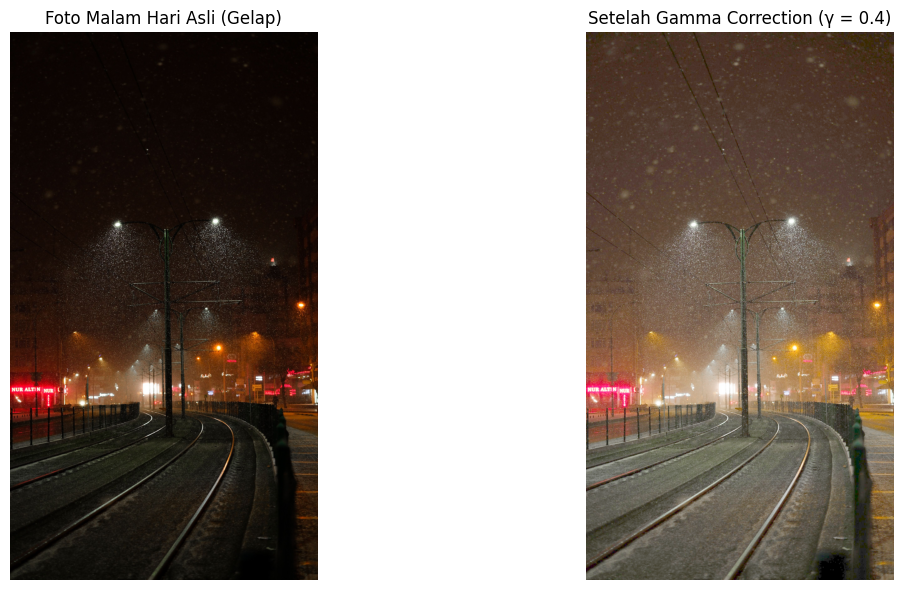

In [19]:
img = cv2.imread('/content/drive/MyDrive/pcvk/Gambar/malam_kota.jpg')

if img is None:
    print("Error: Gambar tidak ditemukan. Silakan unggah gambar terlebih dahulu.")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gamma = 0.4

    img_normalized = img_rgb.astype(np.float32) / 255.0
    gamma_corrected = 255.0 * (img_normalized ** gamma)

    gamma_corrected = np.clip(gamma_corrected, 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(img_rgb)
    axes[0].set_title('Foto Malam Hari Asli (Gelap)')
    axes[0].axis('off')

    axes[1].imshow(gamma_corrected)
    axes[1].set_title(f'Setelah Gamma Correction (γ = {gamma})')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

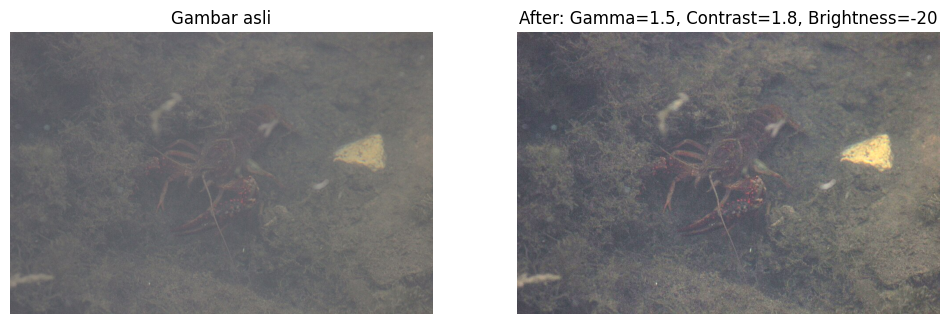

In [30]:
img = cv2.imread('/content/drive/MyDrive/pcvk/Gambar/crayfish.jpg')

if img is None:
    print("Error: Gambar crayfish.jpg tidak ditemukan.")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gamma = 1.5
    a = 1.8
    b = -20

    img_normalized = img_rgb.astype(np.float32) / 255.0
    gamma_corrected = 255.0 * (img_normalized ** gamma)
    gamma_corrected = np.clip(gamma_corrected, 0, 255).astype(np.uint8)

    final_img = np.clip(a * gamma_corrected.astype(float) + b, 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(img_rgb)
    axes[0].set_title('Gambar asli')
    axes[0].axis('off')

    axes[1].imshow(final_img)
    axes[1].set_title(f'After: Gamma={gamma}, Contrast={a}, Brightness={b}')
    axes[1].axis('off')

    plt.show()